# CT + Dose + ROI 分步运行 Notebook

这个 Notebook 将 main.py 按逻辑拆成多个 Cell，便于逐步调试：
1. 导入依赖并初始化运行环境
2. 加载配置并解析输入路径
3. 读取 CT / Dose 数据
4. 重采样与切片选择
5. 读取 RTSTRUCT 并构建 ROI 掩膜
6. 渲染并保存四面板图

建议按顺序首次运行；后续可只重跑某一步。

In [1]:
# Cell 1: 导入所有需要的包和模块
import os
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import nibabel as nib

from ReadNifti import ReadNifti
from cli_config import (
    build_cli_parser,
    get_param,
    load_config_file,
    parse_roi_ids,
    to_abs_path,
)
from data_paths import resolve_data_paths
from roi_config import build_roi_style_from_config
from utils import (
    resample,
    extract_slices,
    load_roi_reference_geometry,
    build_roi_masks,
    load_structures,
)
from visualization import RenderConfig, render_dose_overlay

# 让工作目录稳定在 viewer 目录，避免相对路径问题
base_dir = Path.cwd()
if not (base_dir / "main.py").exists() and (base_dir / "viewer" / "main.py").exists():
    base_dir = base_dir / "viewer"
os.chdir(base_dir)

STATE = {}
print(f"base_dir = {base_dir}")

base_dir = d:\python文件\view_ctdose\viewer


In [2]:
# Cell 2: 加载配置、解析参数与数据路径
parser = build_cli_parser()
args = parser.parse_args(args=[])

# Notebook 默认使用 viewer/config.yaml，也可手工改成其他配置文件
args.config = args.config or "config.yaml"

config_path = args.config
if config_path is None:
    default_config = os.path.join(base_dir, "config.yaml")
    if os.path.isfile(default_config):
        config_path = default_config

cfg = load_config_file(config_path, str(base_dir))

overrides = {
    "ct_nii_file": to_abs_path(get_param(args, cfg, "ct_nii", "ct_nii"), str(base_dir)),
    "dose_nii_file": to_abs_path(get_param(args, cfg, "dose_nii", "dose_nii"), str(base_dir)),
    "rs_dcm_file": to_abs_path(get_param(args, cfg, "rs_dcm", "rs_dcm"), str(base_dir)),
    "ct_dicom_dir": to_abs_path(get_param(args, cfg, "ct_dicom_dir", "ct_dicom_dir"), str(base_dir)),
    "rd_dcm_file": to_abs_path(get_param(args, cfg, "rd_dcm", "rd_dcm"), str(base_dir)),
}
ct_nii_file, dose_nii_file, rs_dcm_file, ct_dicom_dir, rd_dcm_file = resolve_data_paths(str(base_dir), overrides)

selected_roi_ids = parse_roi_ids(get_param(args, cfg, "roi_ids", "roi_ids", default=None))
roi_map, roi_colors, roi_linewidths, unknown_ids = build_roi_style_from_config(cfg, selected_roi_ids)
if unknown_ids:
    print(f"警告: 以下ROI编号未在默认ROI_MAP中定义，已忽略: {unknown_ids}")

dose_threshold_ratio = float(get_param(args, cfg, "dose_threshold_ratio", "dose_threshold_ratio", default=0.1))
scaling_policy = get_param(args, cfg, "scaling_policy", "scaling_policy", default="dicom_or_config")
output_dpi = int(get_param(args, cfg, "dpi", "dpi", default=150))
title = get_param(args, cfg, "title", "title", default="Head & Neck Cancer - Dose Distribution (CT+Dose)")
output_path = to_abs_path(
    get_param(args, cfg, "output", "output", default=os.path.join(os.path.dirname(str(base_dir)), "ct_dose_roi_four_panel.png")),
    str(base_dir),
)

STATE.update({
    "args": args,
    "cfg": cfg,
    "ct_nii_file": ct_nii_file,
    "dose_nii_file": dose_nii_file,
    "rs_dcm_file": rs_dcm_file,
    "ct_dicom_dir": ct_dicom_dir,
    "rd_dcm_file": rd_dcm_file,
    "roi_map": roi_map,
    "roi_colors": roi_colors,
    "roi_linewidths": roi_linewidths,
    "dose_threshold_ratio": dose_threshold_ratio,
    "scaling_policy": scaling_policy,
    "output_dpi": output_dpi,
    "title": title,
    "output_path": output_path,
})

print("配置加载完成")
print(f"CT NIfTI:      {ct_nii_file}")
print(f"Dose NIfTI:    {dose_nii_file}")
print(f"RTSTRUCT:      {rs_dcm_file}")
print(f"CT DICOM dir:  {ct_dicom_dir}")
print(f"RTDOSE:        {rd_dcm_file}")
print(f"输出路径:       {output_path}")

配置加载完成
CT NIfTI:      d:\python文件\ct_dose_view\Volume data\201 Extended FOV iDose (3).nii
Dose NIfTI:    d:\python文件\ct_dose_view\Volume data\205 Eclipse Doses.nii
RTSTRUCT:      d:\python文件\ct_dose_view\NPC_401\RS.NPC_401.AutoPlan.dcm
CT DICOM dir:  d:\python文件\ct_dose_view\NPC_401
RTDOSE:        d:\python文件\ct_dose_view\NPC_401\RD.NPC_401.PlanOpt.dcm
输出路径:       d:\python文件\view_ctdose\ct_dose_roi_four_panel.png


In [3]:
# Cell 3: 读取CT / Dose数据（你可以单独反复测试这一段）
required = ["ct_nii_file", "dose_nii_file", "rd_dcm_file", "scaling_policy", "args", "cfg"]
missing = [k for k in required if k not in STATE]
if missing:
    raise RuntimeError(f"请先运行 Cell 2，缺少: {missing}")

ct_img_nib = nib.load(STATE["ct_nii_file"])
dose_img_nib = nib.load(STATE["dose_nii_file"])

nifti_reader = ReadNifti()
ct_array, ct_origin, ct_spacing, vmin, vmax = nifti_reader.load_ct_nifti(STATE["ct_nii_file"])

dose_grid_scaling = ReadNifti.load_dose_grid_scaling_from_rtdose(STATE["rd_dcm_file"])
config_scale = get_param(STATE["args"], STATE["cfg"], "dose_scale_factor", "dose_scale_factor", default=None)
if config_scale is None:
    config_scale_env = os.environ.get("DOSE_SCALE_FACTOR")
    if config_scale_env:
        config_scale = float(config_scale_env)

dose_array, dose_origin, dose_spacing = nifti_reader.load_dose_nifti(
    STATE["dose_nii_file"],
    dose_grid_scaling=dose_grid_scaling,
    config_scale=config_scale,
    scaling_policy=STATE["scaling_policy"],
)

STATE.update({
    "ct_img_nib": ct_img_nib,
    "dose_img_nib": dose_img_nib,
    "nifti_reader": nifti_reader,
    "ct_array": ct_array,
    "ct_origin": ct_origin,
    "ct_spacing": ct_spacing,
    "vmin": vmin,
    "vmax": vmax,
    "dose_array": dose_array,
    "dose_origin": dose_origin,
    "dose_spacing": dose_spacing,
})

print("数据读取完成")
print(f"CT shape:     {ct_array.shape}")
print(f"Dose shape:   {dose_array.shape}")
print(f"CT spacing:   {ct_spacing}")
print(f"Dose spacing: {dose_spacing}")

数据读取完成
CT shape:     (74, 1024, 1024)
Dose shape:   (216, 131, 251)
CT spacing:   [5.         0.68359375 0.68359375]
Dose spacing: [1.66666663 2.         2.        ]


In [4]:
# Cell 4: 重采样Dose到CT网格，并确定展示切片
required = [
    "ct_array", "ct_origin", "ct_spacing",
    "dose_array", "dose_origin", "dose_spacing",
    "ct_img_nib", "dose_img_nib", "args", "cfg"
]
missing = [k for k in required if k not in STATE]
if missing:
    raise RuntimeError(f"请先运行 Cell 3，缺少: {missing}")

_, _, _, dose_on_ct = resample(
    STATE["ct_array"],
    STATE["ct_origin"],
    STATE["ct_spacing"],
    STATE["dose_array"],
    STATE["dose_origin"],
    STATE["dose_spacing"],
    ct_affine=STATE["ct_img_nib"].affine,
    dose_affine=STATE["dose_img_nib"].affine,
)

z_idx = get_param(STATE["args"], STATE["cfg"], "z_idx", "z_idx", default=None)
y_idx = get_param(STATE["args"], STATE["cfg"], "y_idx", "y_idx", default=None)
x_idx = get_param(STATE["args"], STATE["cfg"], "x_idx", "x_idx", default=None)
z_mid, y_mid, x_mid = extract_slices(STATE["ct_array"], dose_on_ct, z_idx=z_idx, y_idx=y_idx, x_idx=x_idx)

STATE.update({
    "dose_on_ct": dose_on_ct,
    "z_mid": z_mid,
    "y_mid": y_mid,
    "x_mid": x_mid,
})

print("重采样完成")
print(f"Dose on CT shape: {dose_on_ct.shape}")
print(f"切片索引: z={z_mid}, y={y_mid}, x={x_mid}")

✓ Axial (Z=37): ct (1024, 1024), dose (1024, 1024)
✓ Coronal (Y=512): ct (74, 1024), dose (74, 1024)
✓ Sagittal (X=512): ct (74, 1024), dose (74, 1024)
重采样完成
Dose on CT shape: (74, 1024, 1024)
切片索引: z=37, y=512, x=512


In [5]:
# Cell 5: 读取结构集并构建ROI掩膜
required = ["rs_dcm_file", "ct_dicom_dir", "ct_array", "roi_map"]
missing = [k for k in required if k not in STATE]
if missing:
    raise RuntimeError(f"请先运行 Cell 2 和 Cell 3，缺少: {missing}")

structures = load_structures(STATE["rs_dcm_file"])
rois = structures["rois"]

roi_ct_origin, roi_ct_spacing, roi_ct_orientation = load_roi_reference_geometry(STATE["ct_dicom_dir"])
roi_masks = build_roi_masks(
    rois,
    STATE["ct_array"].shape,
    roi_ct_origin,
    roi_ct_spacing,
    roi_ct_orientation,
    STATE["roi_map"],
)

STATE.update({
    "structures": structures,
    "rois": rois,
    "roi_masks": roi_masks,
})

print(f"ROI 总数: {len(rois)}")
print(f"可用 ROI mask 数: {len(roi_masks)}")

ROI 总数: 72
可用 ROI mask 数: 11


重采样完成
  CT shape:              (74, 1024, 1024)
  Dose resampled shape:  (74, 1024, 1024)
  Dose max:              75.74 Gy
  Dose scaling:
    source:              dicom_dose_grid_scaling
    input unit:          raw_grid
    output unit:         Gy
    scale factor:        0.00007147
    raw max:             1063640.0000
    scaled max:          76.0206
  Available ROI masks:   11
已保存: d:\python文件\view_ctdose\ct_dose_roi_four_panel.png


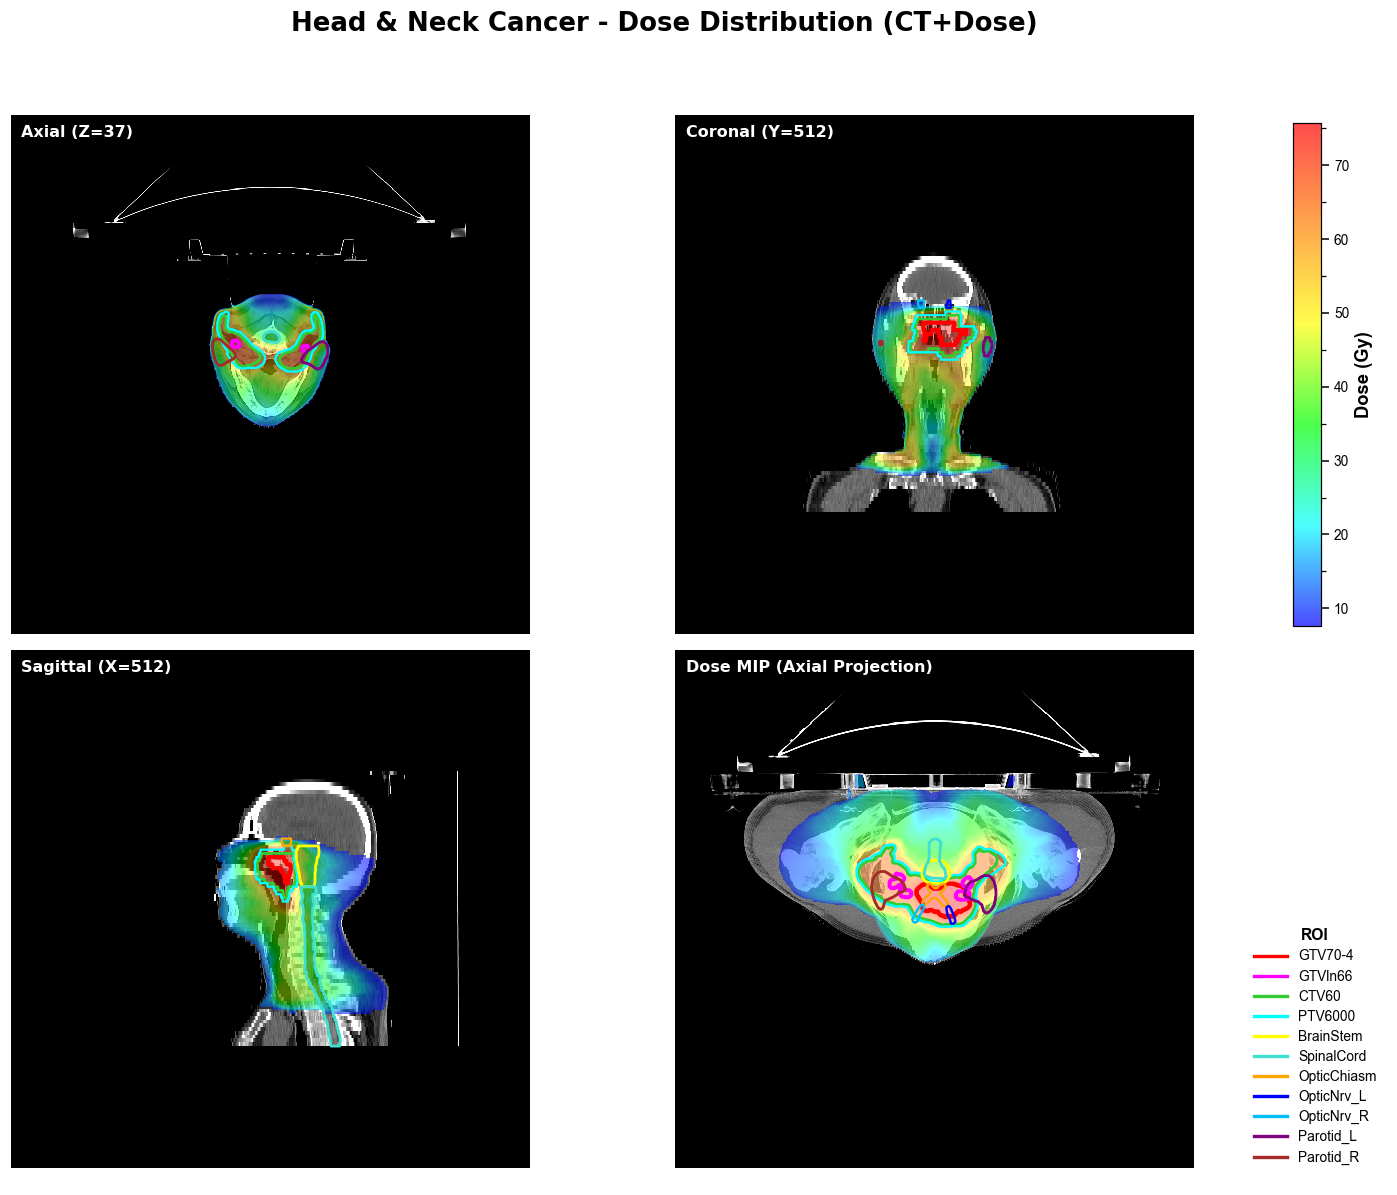

In [7]:
# Cell 6: 渲染并保存最终四面板图
required = [
    "ct_array", "dose_on_ct", "roi_masks", "roi_map", "roi_colors", "roi_linewidths",
    "ct_spacing", "z_mid", "y_mid", "x_mid", "vmin", "vmax",
    "dose_threshold_ratio", "title", "output_path", "output_dpi", "nifti_reader"
]
missing = [k for k in required if k not in STATE]
if missing:
    raise RuntimeError(f"请先运行前面的 Cell，缺少: {missing}")

dose_max = float(STATE["dose_on_ct"].max())
scaling_info = STATE["nifti_reader"].last_dose_scaling_info

print("重采样完成")
print(f"  CT shape:              {STATE['ct_array'].shape}")
print(f"  Dose resampled shape:  {STATE['dose_on_ct'].shape}")
print(f"  Dose max:              {dose_max:.2f} Gy")
print("  Dose scaling:")
print(f"    source:              {scaling_info.get('scale_source', 'none')}")
print(f"    input unit:          {scaling_info.get('input_unit', 'raw_grid')}")
print(f"    output unit:         {scaling_info.get('output_unit', 'Gy')}")
print(f"    scale factor:        {scaling_info.get('scale_factor', 1.0):.8f}")
print(f"    raw max:             {scaling_info.get('raw_max', 0.0):.4f}")
print(f"    scaled max:          {scaling_info.get('scaled_max', 0.0):.4f}")
print(f"  Available ROI masks:   {len(STATE['roi_masks'])}")

render_cfg = RenderConfig(
    roi_map=STATE["roi_map"],
    colors=STATE["roi_colors"],
    linewidths=STATE["roi_linewidths"],
)

fig = render_dose_overlay(
    ct_array=STATE["ct_array"],
    dose_on_ct=STATE["dose_on_ct"],
    roi_masks=STATE["roi_masks"],
    config=render_cfg,
    ct_spacing=STATE["ct_spacing"],
    z_idx=STATE["z_mid"],
    y_idx=STATE["y_mid"],
    x_idx=STATE["x_mid"],
    vmin=STATE["vmin"],
    vmax=STATE["vmax"],
    dose_max=dose_max,
    dose_threshold_ratio=STATE["dose_threshold_ratio"],
    title=STATE["title"],
)

output_dir = os.path.dirname(STATE["output_path"])
if output_dir:
    os.makedirs(output_dir, exist_ok=True)
fig.savefig(STATE["output_path"], dpi=STATE["output_dpi"], facecolor="white")

print(f"已保存: {STATE['output_path']}")
plt.show()

## 常用调试方式

- 只测试路径/配置：运行 Cell 1 -> Cell 2
- 只测试数据读取：运行 Cell 1 -> Cell 2 -> Cell 3
- 调整切片位置：修改 Cell 4 的 z_idx/y_idx/x_idx 来源（配置或临时变量）后重跑 Cell 4 与 Cell 6
- 调整 ROI 样式：修改配置文件后重跑 Cell 2、Cell 5、Cell 6